In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Индивидуальное задание №1

## Задание 1
Сделать изображение на телефон или фотоаппарат. Из-за неидеальности цифровой техники, на нём получатся искажения.

In [16]:
image = cv2.imread('image.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

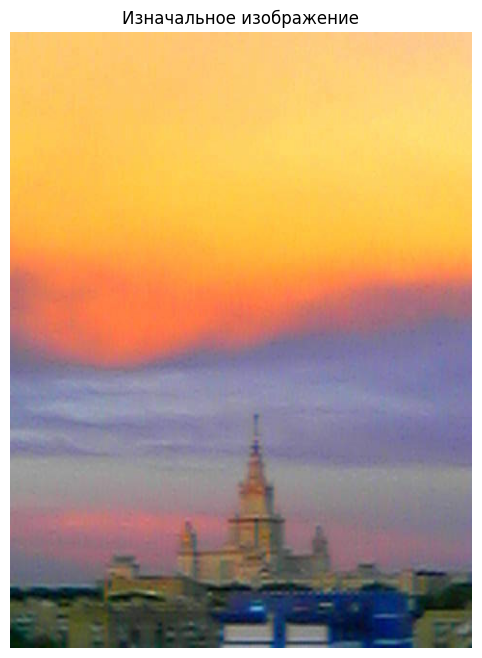

In [17]:
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.title('Изначальное изображение')
plt.axis('off')
plt.show()

## Задание 2
Попытаться улучшить полученное изображение с помощью изученных методов. В отчёте пояснить, почему выбрали именно эти методы.

### Выбор методов для улучшения изображения:
Задачи обработки изображений часто сталкиваются со специфическими проблемами цифровых камер (телефонов): цветовой шум, малая контрастность, отсутствие резкости из-за неидеальной оптики.

1. **Билатеральный фильтр (Bilateral Filter)**:
Используется для подавления цифрового шума (шум матрицы при слабом или искусственном освещении). В отличие от медианного или гауссова размытия, билатеральный фильтр сохраняет жесткие границы объектов, размывая только однородные области. Это позволяет сделать изображение чище без потери общей резкости.

2. **Эквализация гистограммы в пространстве LAB (через алгоритм CLAHE)**:
Этот метод повышает контрастность изображения, компенсируя неидеальную экспозицию. Метод устраняет недоэкспонированные и пересвеченные участки, работая с контрастностью на уровне малых блоков (tiles), что избегает проблем глобальной эквализации гистограммы (избыточной яркости и пересветов). Переход в пространство LAB необходим, чтобы применять CLAHE только к яркостному каналу L, не искажая исходный цветовой баланс (каналы a и b).

3. **Увеличение резкости (Unsharp Masking)**:
Неидеальная оптика дает общий эффект замыливания, особенно после применения первого шага. Метод Unsharp Mask находит мелкие детали (через вычисление разницы между исходным изображением и размытым фильтром Гаусса) и добавляет их обратно, усиливая резкость границ.

In [18]:
filtered_image = cv2.bilateralFilter(image_rgb, d=9, sigmaColor=75, sigmaSpace=75)
lab = cv2.cvtColor(filtered_image, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
cl = clahe.apply(l)
limg = cv2.merge((cl, a, b))
enhanced_image = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
gaussian_blur = cv2.GaussianBlur(enhanced_image, (9, 9), 10.0)
sharpened_image = cv2.addWeighted(enhanced_image, 1.5, gaussian_blur, -0.5, 0)

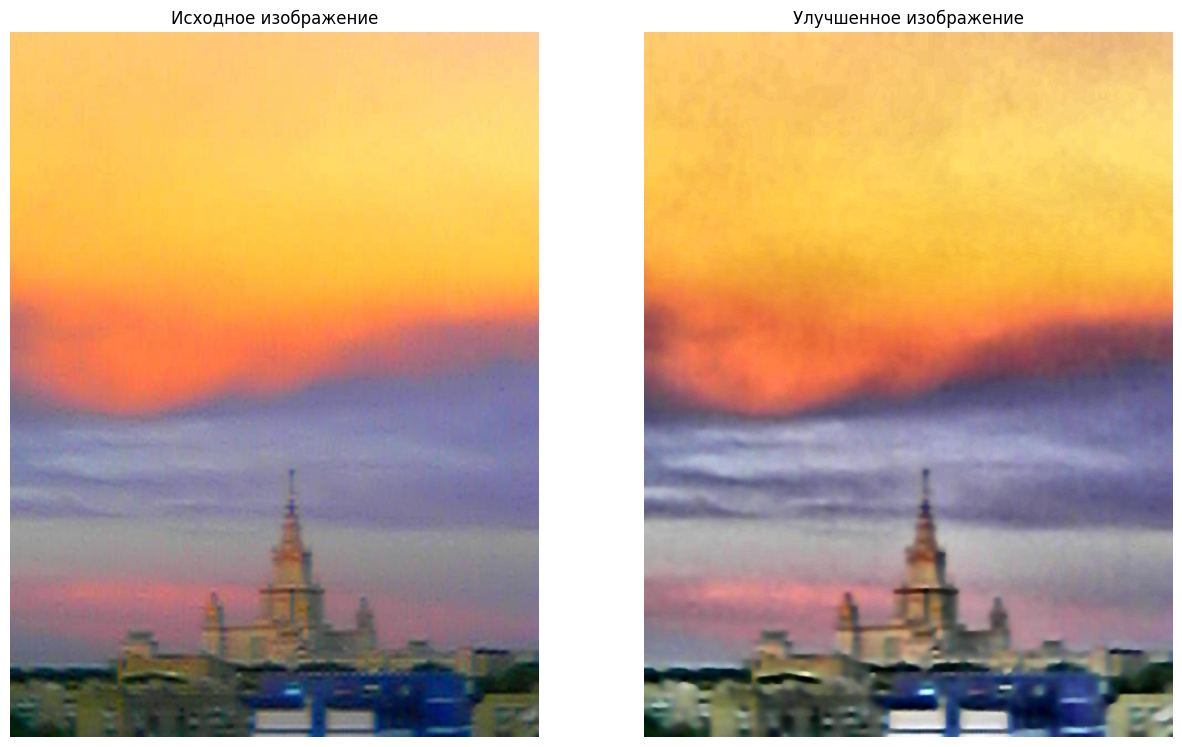

In [19]:
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sharpened_image)
plt.title('Улучшенное изображение')
plt.axis('off')
plt.show()

## Задание 3
Выбрать изображение для сегментации. Провести предварительную обработку и сегментацию изображения методом водоразделов.

### Алгоритм водоразделов:

Для сегментации используется алгоритм водоразделов, но чтобы он не создавал слишком много сегментов (oversplitting) из-за шума, важна предобработка изображения:
1. Перевод в градации серого - необходимо для пороговой обработки.
2. Бинаризация Оцу позволяет автоматически найти лучший порог для разделения объектов изображения и фона.
3. Морфологические операции (Opening) сглаживают границы и удаляют случайные белые мелкие точки (ложные объекты).
4. Расширение (Dilation) формирует уверенный задний план (sure background) за счет разрастания объектов.
5. Трансформация расстояний (Distance Transform) позволяет найти "уверенный передний план" (sure foreground). Он указывает пиксели, которые гарантированно принадлежат самим объектам. 
6. Вычитание уверенного переднего плана из заднего дает "неизвестную область" (границы).
7. Задаются маркеры, и запускается алгоритм водораздела (`cv2.watershed`), который аккуратно распределяет неизвестную область по сегментам. В итоге мы получаем чёткие границы объектов, выделенные красным цветом.

In [20]:
img_seg = cv2.imread('image.jpg')
gray = cv2.cvtColor(img_seg, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(img_seg, markers)
img_seg[markers == -1] = [255, 0, 0]
img_seg_rgb = cv2.cvtColor(img_seg, cv2.COLOR_BGR2RGB)

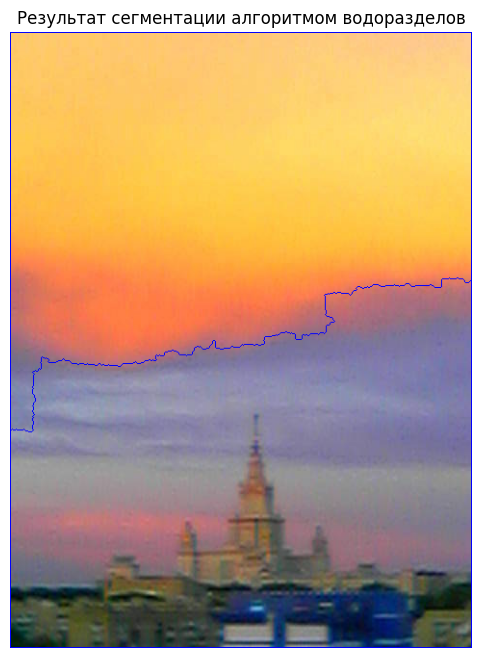

In [21]:
plt.figure(figsize=(10, 8))
plt.imshow(img_seg_rgb)
plt.title('Результат сегментации алгоритмом водоразделов')
plt.axis('off')
plt.show()

### Выполнил: Мелешенко Николай Артурович